<a href="https://colab.research.google.com/github/kai24-cell/research-Think-in-English-Output-in-Japanese-Mitigating-GPU-Workloads-through-Translation-Offloading/blob/main/LLMEx.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

データを読み込んでいます: /content/drive/MyDrive/LLM_Energy_Experiment/experiment_results_summary.csv
有効なデータ件数: 1000 / 1000 件



/tmp/ipykernel_765/2085083026.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.boxplot(x='Approach', y='Power Consumption (kWh)', data=plot_data,


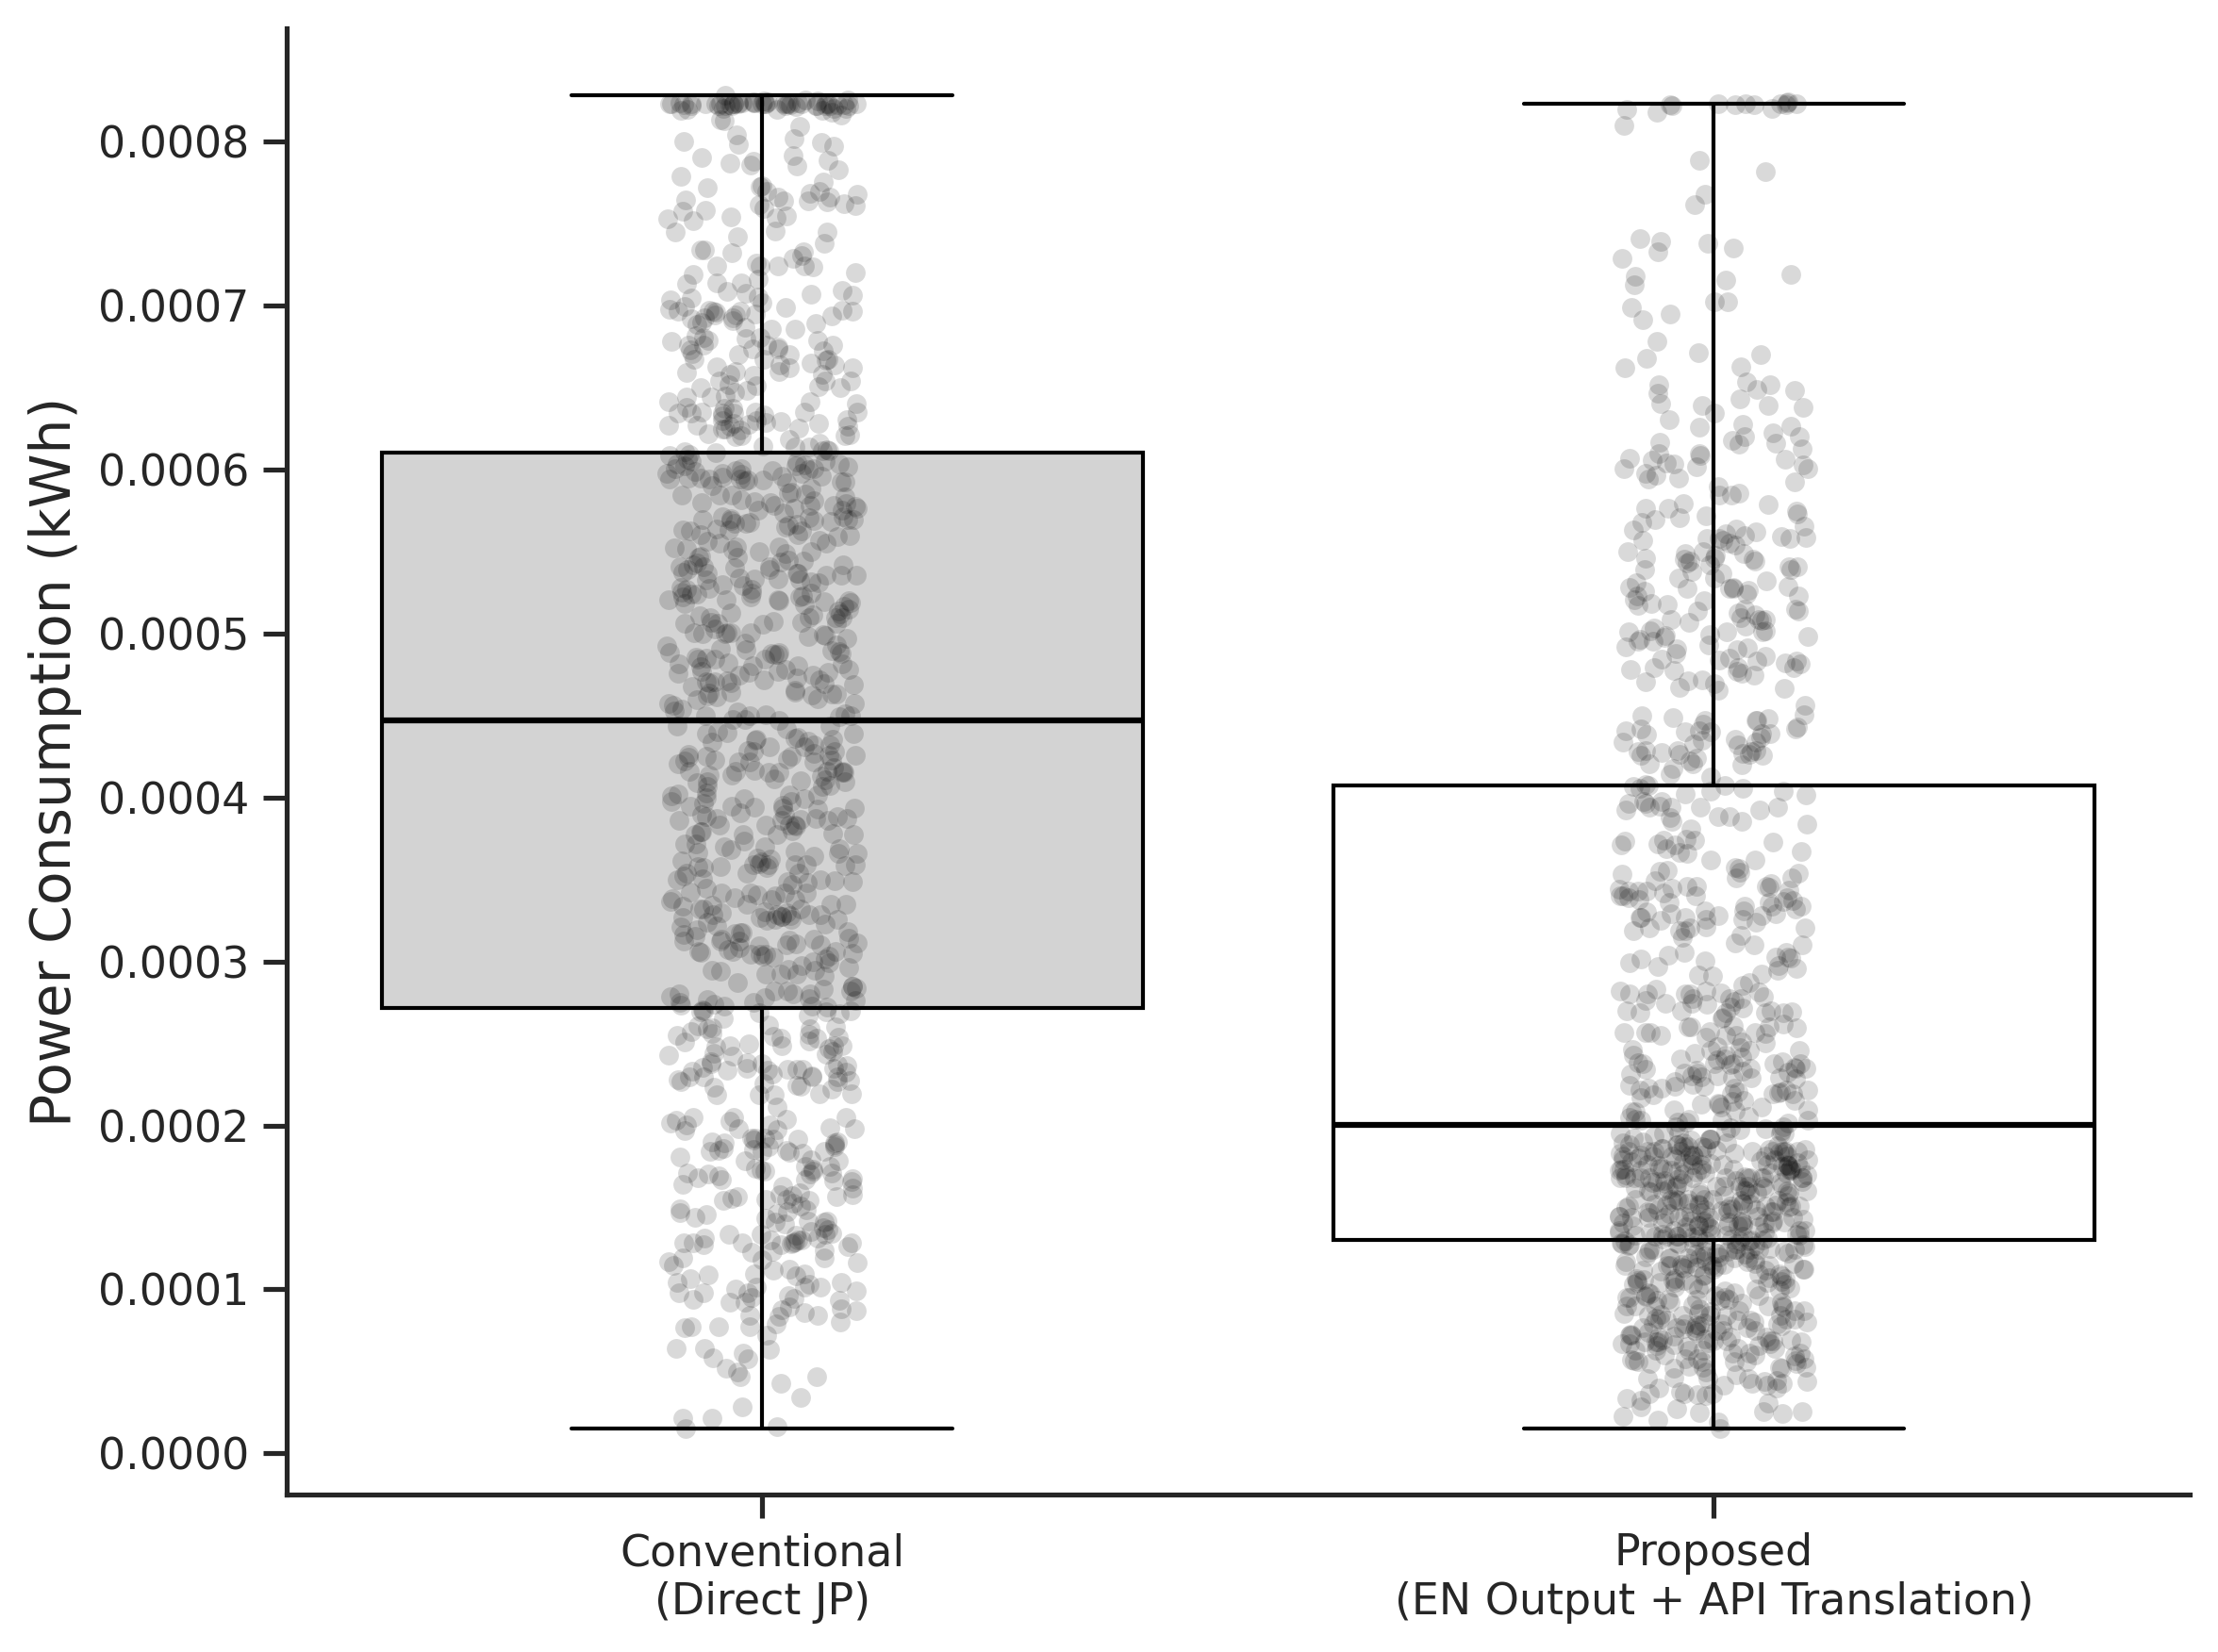

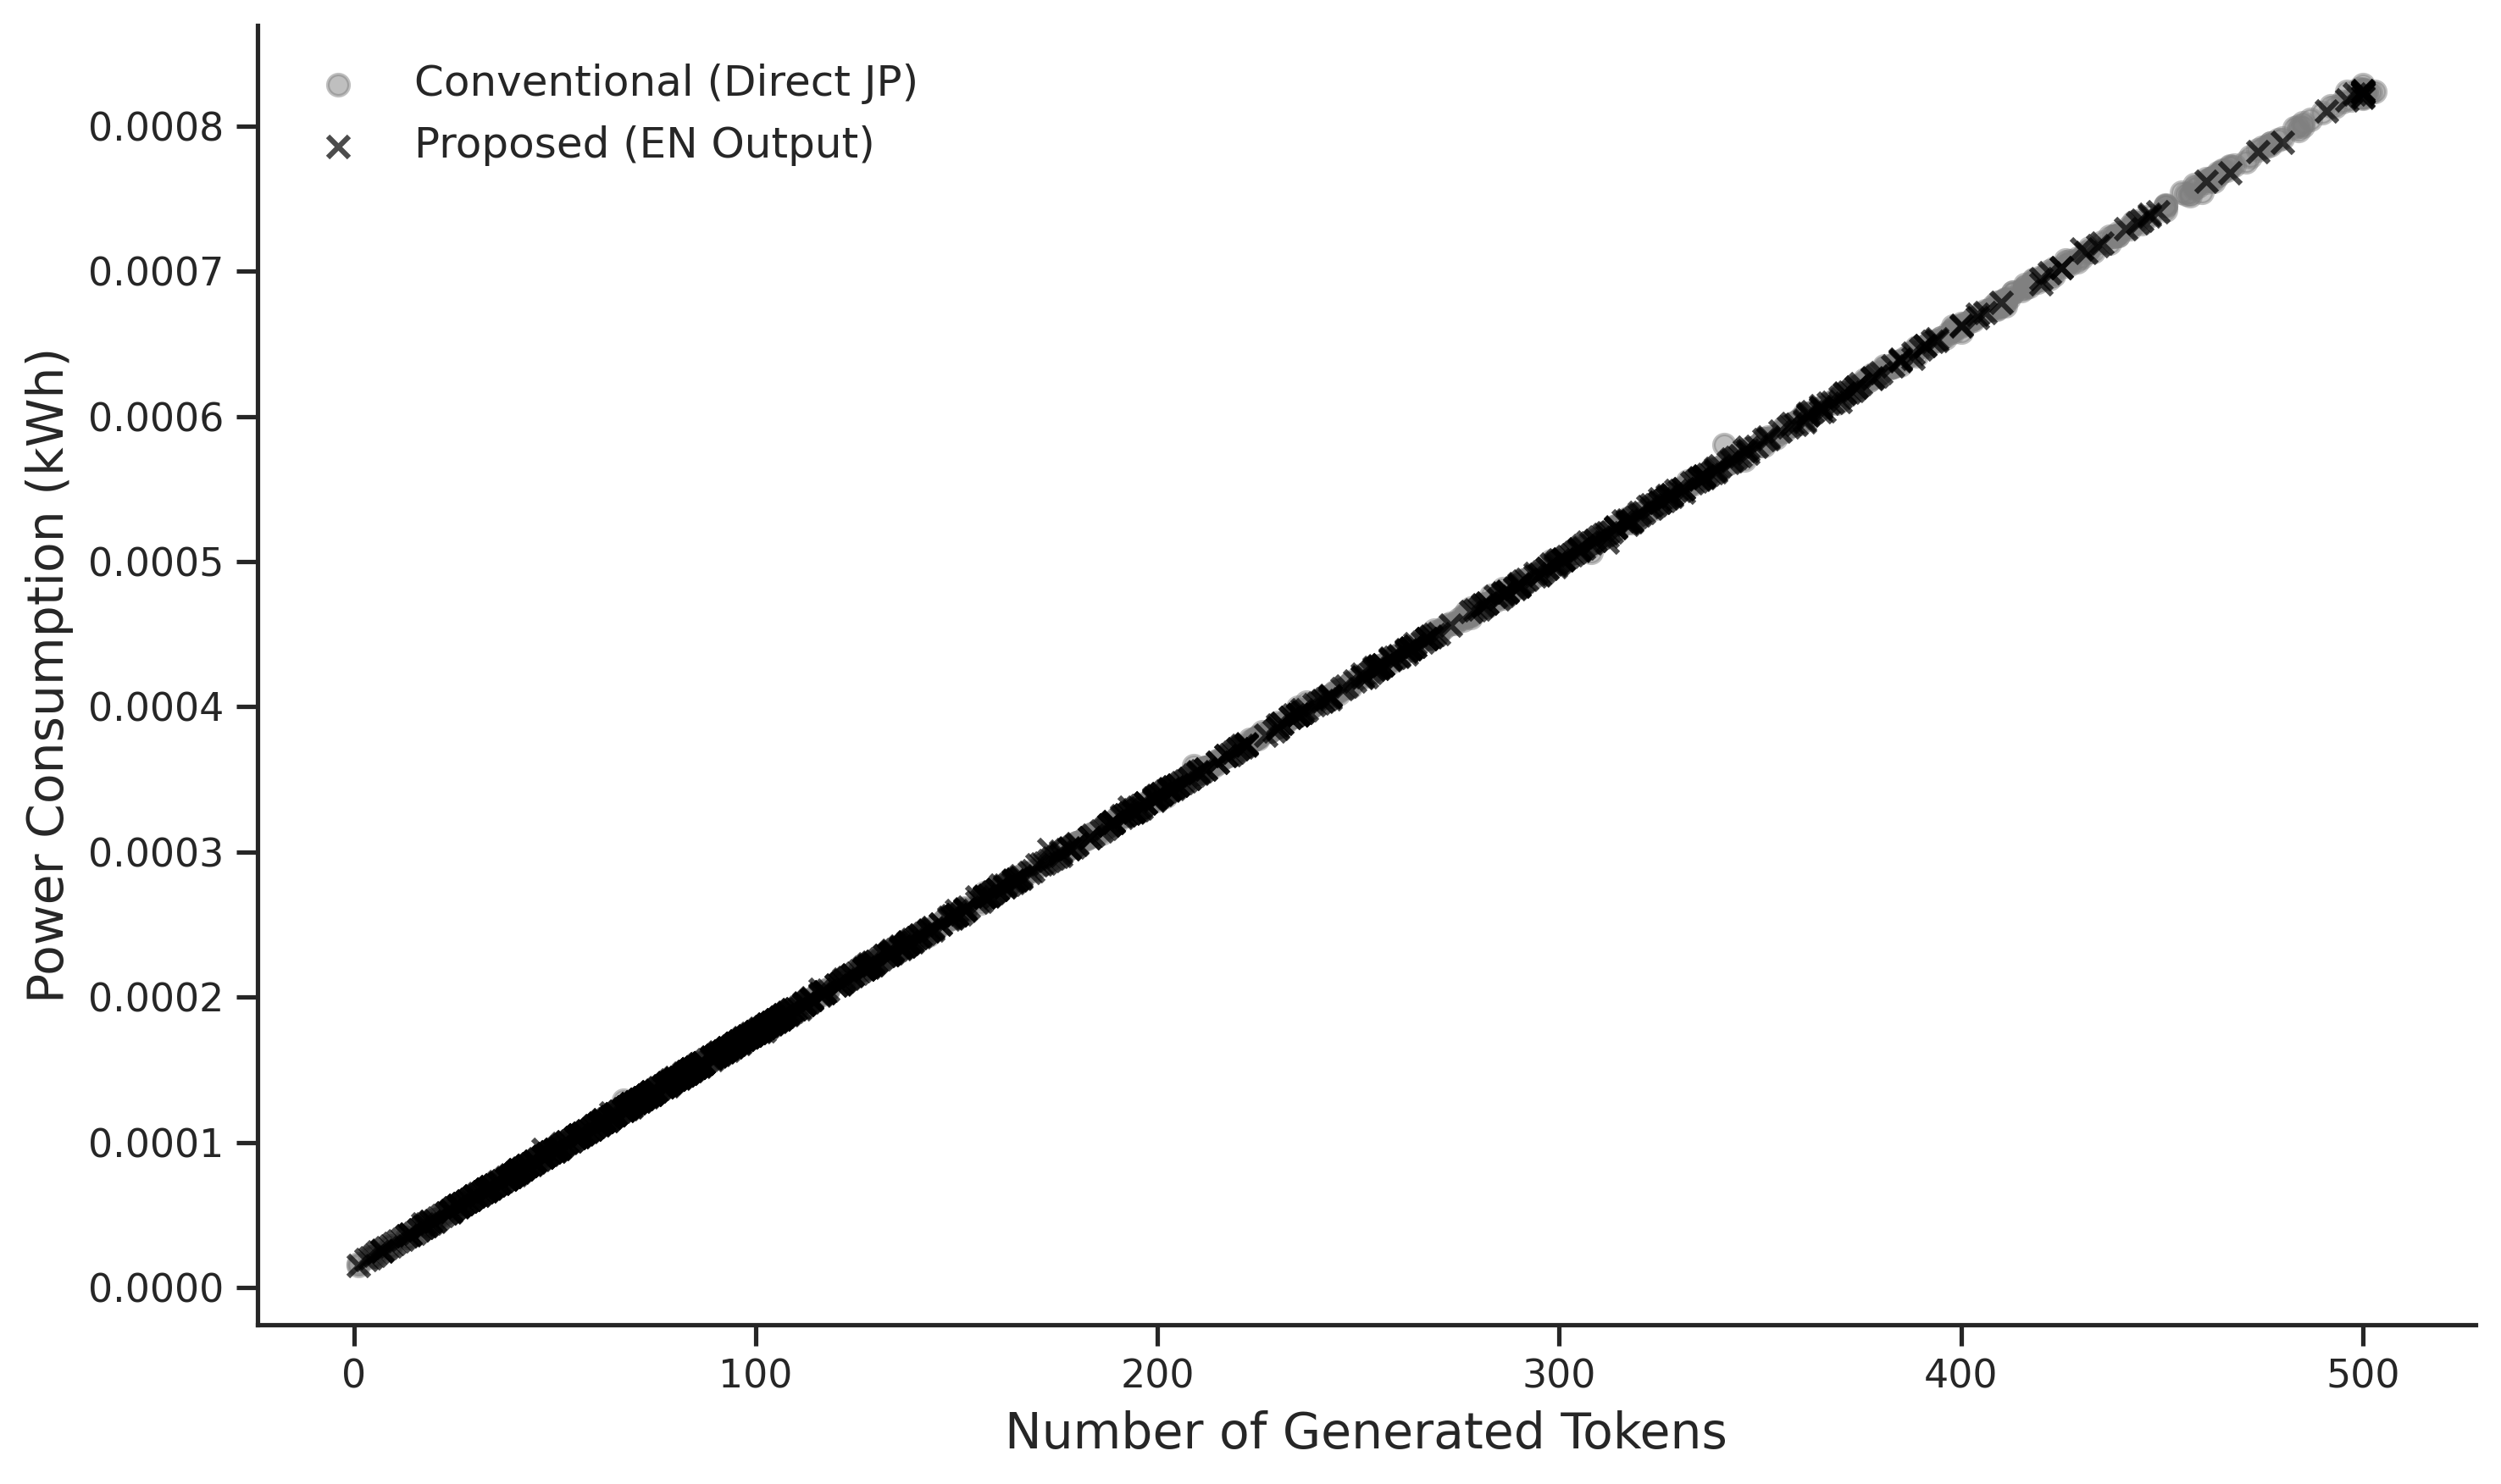

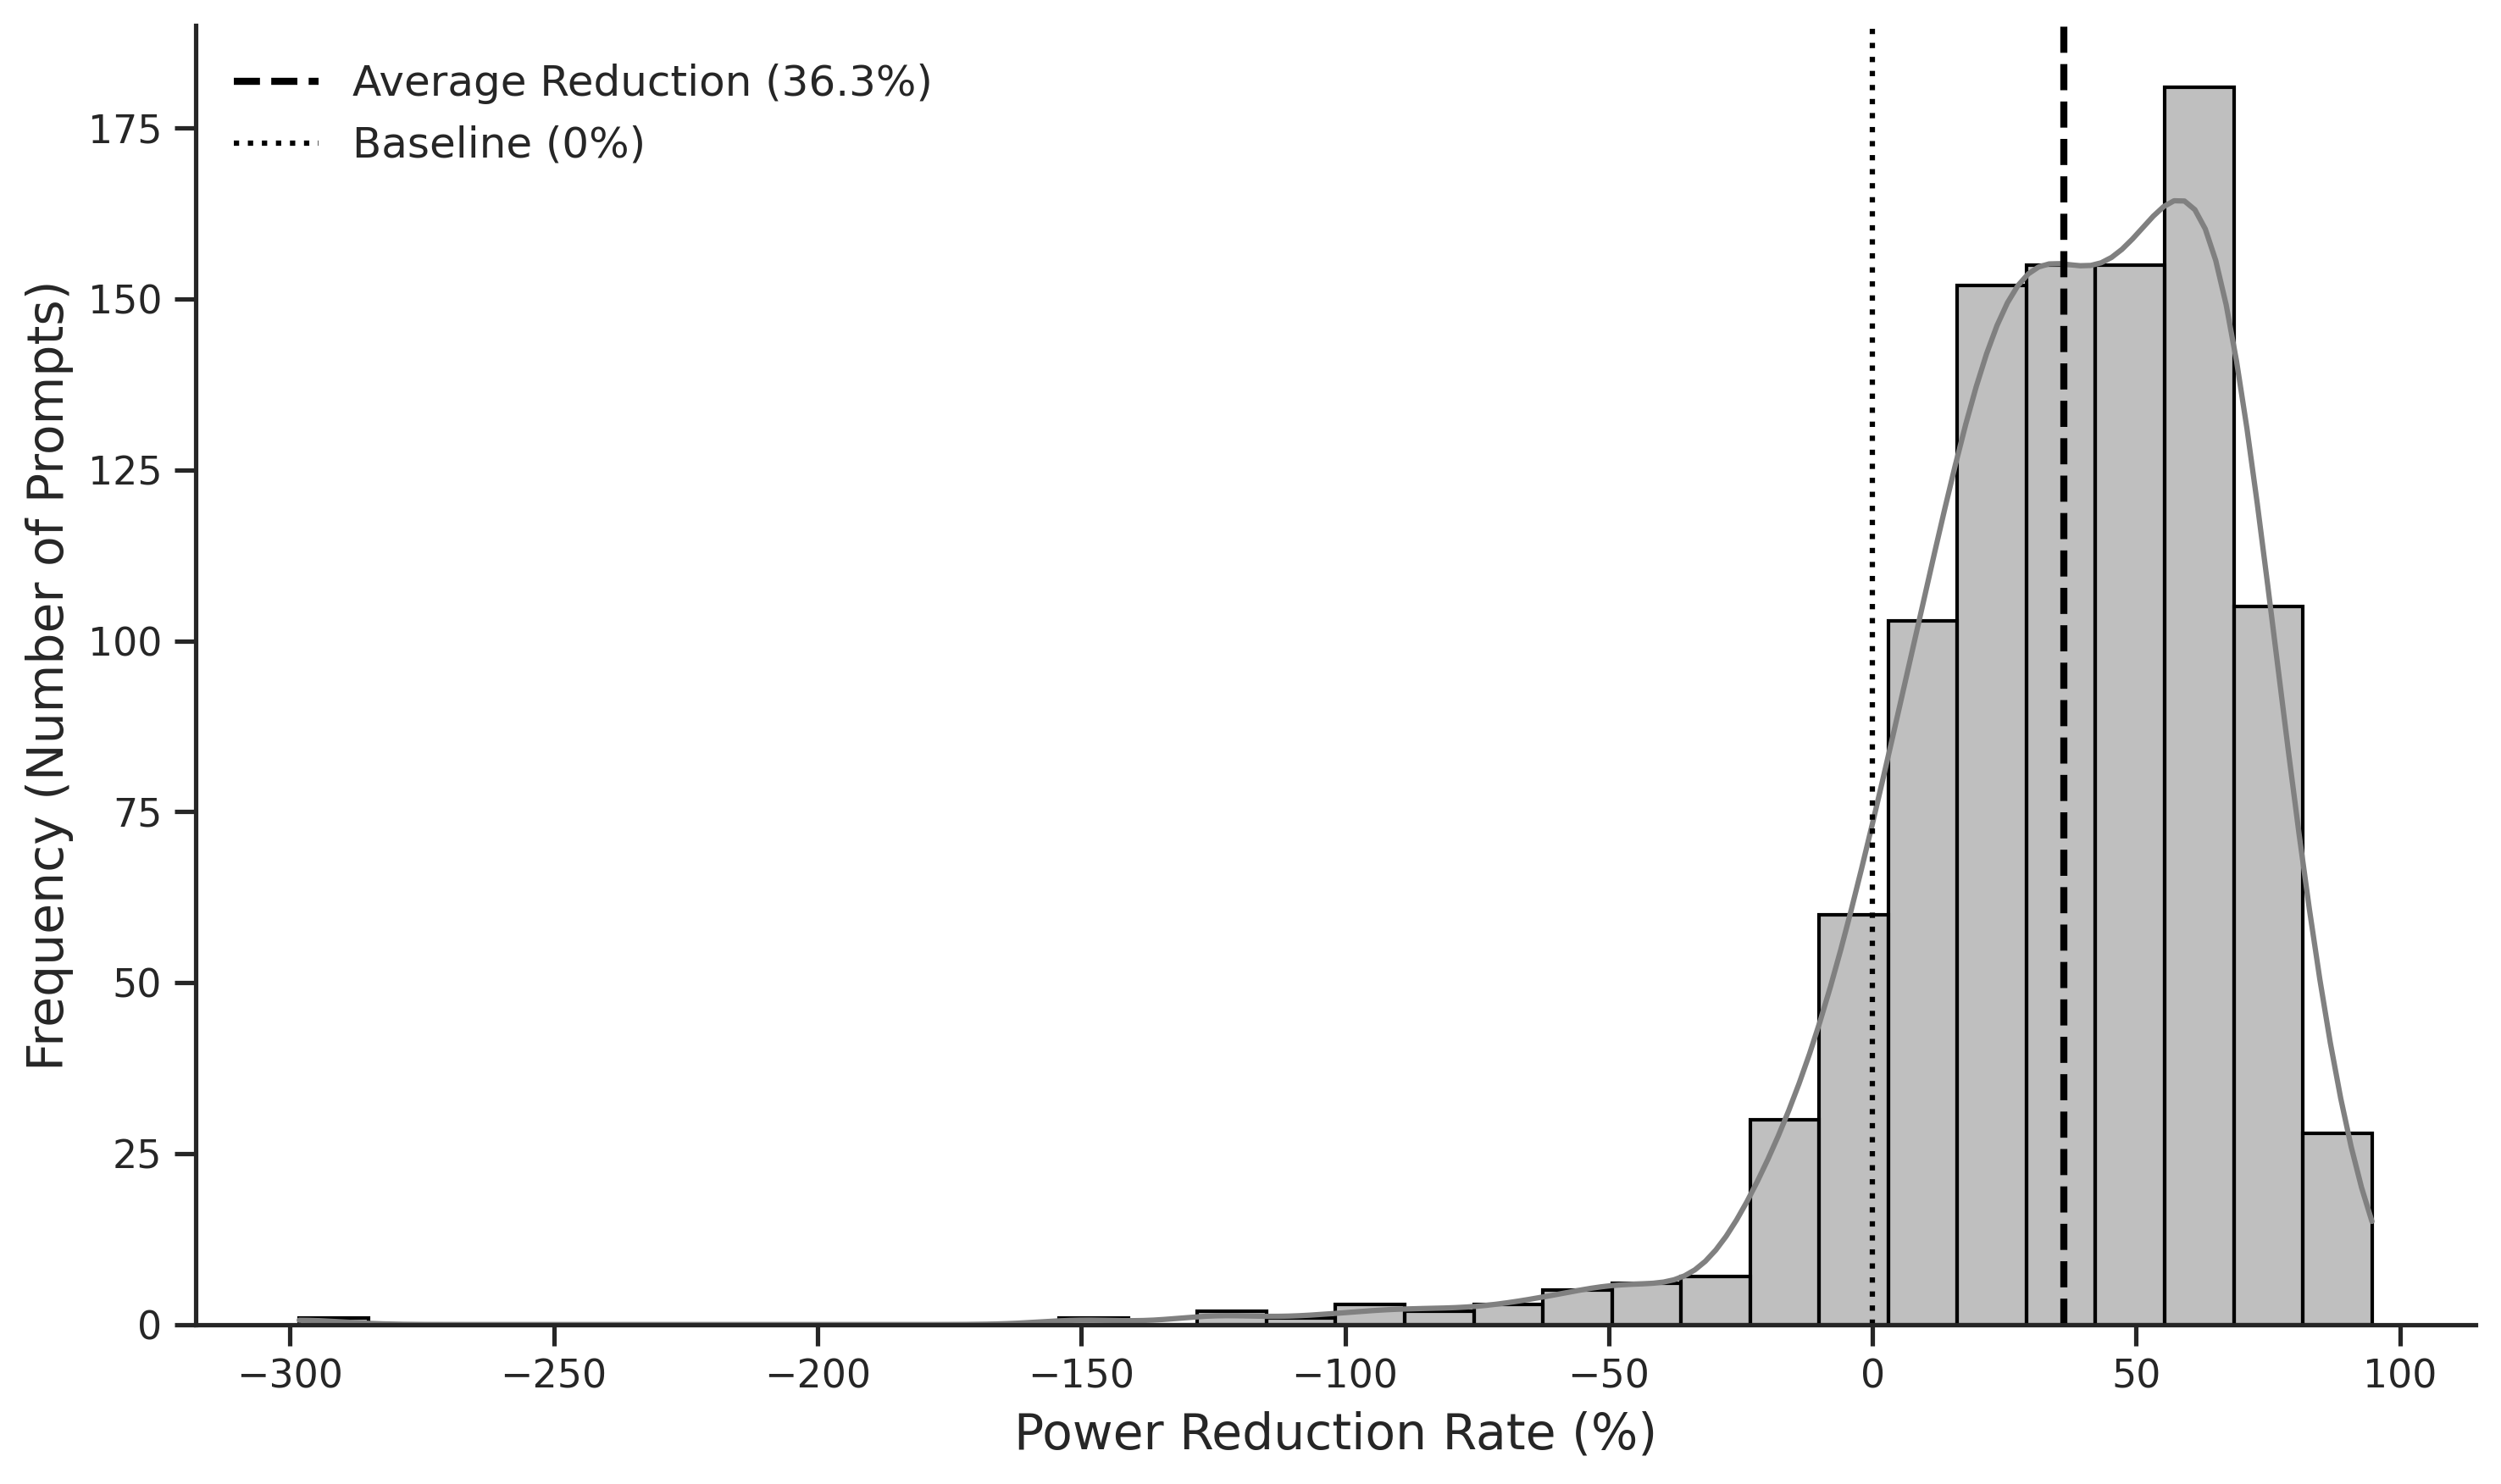

✅ すべてのグラフ（白黒・学術論文仕様）が保存されました！


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# ==========================================
# 1. データの読み込み
# ==========================================
# まだマウントしていなければマウント
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

csv_path = '/content/drive/MyDrive/LLM_Energy_Experiment/experiment_results_summary.csv'
print(f"データを読み込んでいます: {csv_path}")

df = pd.read_csv(csv_path)

# エラーなどで消費電力が0以下の異常値（ノイズ）があれば除外する前処理
df_clean = df[(df['【JP】消費電力(kWh)'] > 0) & (df['【EN+翻訳】消費電力(kWh)'] > 0)].copy()
print(f"有効なデータ件数: {len(df_clean)} / 1000 件\n")

# ==========================================
# 2. グラフのスタイル設定（完全な論文フォーマット：白黒・外枠なし）
# ==========================================
# 背景を完全な白に、グリッド線なし（ticks）に設定（英語論文向け標準フォントを適用）
sns.set_theme(style="ticks")
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 300  # 高解像度出力（論文用）

# ==========================================
# グラフ1: 消費電力の分布比較（箱ひげ図）
# ==========================================
plt.figure(figsize=(8, 6))

plot_data = pd.DataFrame({
    'Approach': ['Conventional\n(Direct JP)'] * len(df_clean) + ['Proposed\n(EN Output + API Translation)'] * len(df_clean),
    'Power Consumption (kWh)': list(df_clean['【JP】消費電力(kWh)']) + list(df_clean['【EN+翻訳】消費電力(kWh)'])
})

# パレットを白とグレーに設定
gray_palette = ["#d3d3d3", "#ffffff"]

# 箱ひげ図の描画（線の色を黒に指定）
ax1 = sns.boxplot(x='Approach', y='Power Consumption (kWh)', data=plot_data,
                  palette=gray_palette, showfliers=False,
                  boxprops=dict(edgecolor='black'),
                  medianprops=dict(color='black', linewidth=1.5),
                  whiskerprops=dict(color='black'),
                  capprops=dict(color='black'))

# ストリッププロット（点を重ねる）は少し透明な黒色で
sns.stripplot(x='Approach', y='Power Consumption (kWh)', data=plot_data, color="black", alpha=0.15, jitter=True)

# 論文ではグラフ上のタイトルはキャプションに記載するのが一般的なため省略（必要ならコメントアウトを解除）
# plt.title('Comparison of Inference Power Consumption by Approach', fontsize=16, fontweight='bold')
plt.ylabel('Power Consumption (kWh)', fontsize=14)
plt.xlabel('')

sns.despine()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LLM_Energy_Experiment/graph_boxplot_bw.png')
plt.show()

# ==========================================
# グラフ2: 生成トークン数と消費電力の相関（散布図）
# ==========================================
plt.figure(figsize=(10, 6))

# 従来手法：グレーの丸マーカー
plt.scatter(df_clean['【JP】生成トークン数'], df_clean['【JP】消費電力(kWh)'],
            alpha=0.5, color='gray', marker='o', label='Conventional (Direct JP)')

# 提案手法：黒のバツ(×)マーカー（白黒印刷でも丸と明確に区別できる）
plt.scatter(df_clean['【EN】生成トークン数'], df_clean['【EN+翻訳】消費電力(kWh)'],
            alpha=0.7, color='black', marker='x', label='Proposed (EN Output)')

# 論文ではグラフ上のタイトルはキャプションに記載するのが一般的なため省略
# plt.title('Correlation between Generated Tokens and Power Consumption', fontsize=16, fontweight='bold')
plt.xlabel('Number of Generated Tokens', fontsize=14)
plt.ylabel('Power Consumption (kWh)', fontsize=14)
plt.legend(fontsize=12, frameon=False)  # 凡例の枠線も消去

sns.despine()  # 外枠消去

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LLM_Energy_Experiment/graph_scatter_bw.png')
plt.show()

# ==========================================
# グラフ3: 電力削減率の分布（ヒストグラム）
# ==========================================
plt.figure(figsize=(10, 6))

# ヒストグラムはグレーで塗りつぶし、黒枠をつける
sns.histplot(df_clean['電力削減率(%)'], bins=30, kde=True, color='gray', edgecolor='black', alpha=0.5)

# 平均値の線は「黒の破線」で強調
avg_reduction = df_clean['電力削減率(%)'].mean()
plt.axvline(avg_reduction, color='black', linestyle='--', linewidth=2, label=f'Average Reduction ({avg_reduction:.1f}%)')

# 削減率0%（変化なし）の基準線を「黒の点線」で追加
plt.axvline(0, color='black', linestyle=':', linewidth=1.5, label='Baseline (0%)')

# 論文ではグラフ上のタイトルはキャプションに記載するのが一般的なため省略
# plt.title('Distribution of Power Reduction Rates per Prompt', fontsize=16, fontweight='bold')
plt.xlabel('Power Reduction Rate (%)', fontsize=14)
plt.ylabel('Frequency (Number of Prompts)', fontsize=14)
plt.legend(fontsize=12, frameon=False)

sns.despine()  # 外枠消去

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/LLM_Energy_Experiment/graph_histogram_bw.png')
plt.show()

print("✅ すべてのグラフ（白黒・学術論文仕様）が保存されました！")

In [ ]:
!pip install japanize-matplotlib seaborn pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 123.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=d23de510f60f45db8b2c2e20d9ba2037410895f9df75c583b38007d91d549e5f
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib


In [ ]:
!pip install transformers accelerate codecarbon torch deep-translator datasets pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 92.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 121.1 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5


In [ ]:
import time
import torch
import gc
import os
import pandas as pd
from datasets import load_dataset
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
from codecarbon import EmissionsTracker
from deep_translator import GoogleTranslator

# ==========================================
# 0. Google Driveの準備（放置実験の必須対策）
# ==========================================
# シャットダウン時にデータが消滅するのを防ぐため、Driveに直接保存します
from google.colab import drive
print("Google Driveをマウントします。ポップアップが出たら「Google Driveに接続」を許可してください。")
drive.mount('/content/drive')

# 保存先のフォルダを作成（マイドライブ直下の LLM_Energy_Experiment フォルダ）
SAVE_DIR = '/content/drive/MyDrive/LLM_Energy_Experiment/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"結果の保存先を {SAVE_DIR} に設定しました。\n")

# ==========================================
# ⚙️ 実験の基本設定
# ==========================================
NUM_SAMPLES = 1000 # 放置用に1000件などに設定
MAX_TOKENS = 500

# ==========================================
# 1. データセットの準備（論文用の客観的データ）
# ==========================================
print("高品質な日本語指示データセットをダウンロード中...")
dataset = load_dataset("kunishou/databricks-dolly-15k-ja", split="train")

# ランダムにシャッフルして必要な数だけ抽出
dataset = dataset.shuffle(seed=42).select(range(NUM_SAMPLES))
prompts_list = dataset['instruction']

print(f"テスト用のプロンプト {NUM_SAMPLES} 件を準備しました。\n")

# ==========================================
# 2. モデルの準備
# ==========================================
model_id = "Qwen/Qwen2.5-7B-Instruct"
print(f"Loading Model: {model_id} (float16) ...")
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map={"": 0}
)
pipe = pipeline("text-generation", model=model, tokenizer=tokenizer)

# ウォームアップ
print("\n--- GPUウォームアップ ---")
dummy_prompt = tokenizer.apply_chat_template([{"role": "user", "content": "Hello"}], tokenize=False, add_generation_prompt=True)
_ = pipe(dummy_prompt, max_new_tokens=10, pad_token_id=tokenizer.eos_token_id)
torch.cuda.synchronize()

# ==========================================
# 3. 連続計測パイプライン開始
# ==========================================
# CodeCarbonの電力ログもDriveに直接保存するように output_dir を設定
tracker = EmissionsTracker(project_name="web_server_energy_saving", log_level="error", output_dir=SAVE_DIR)
tracker.start()

all_results = []
csv_path = os.path.join(SAVE_DIR, "experiment_results_summary.csv")

# ★追加：中断からの再開（レジューム）機能
start_index = 0
if os.path.exists(csv_path):
    try:
        existing_df = pd.read_csv(csv_path)
        start_index = len(existing_df)
        all_results = existing_df.to_dict('records')
        print(f"📄 既存の保存データを発見しました。{start_index} 件目まで完了済みです。")
        if start_index >= NUM_SAMPLES:
            print("✨ すでに目標の件数に到達しています！")
    except Exception as e:
        print(f"既存データの読み込みに失敗しました: {e}")

for i, base_prompt in enumerate(prompts_list):
    # ★追加：すでに完了している件数はスキップして高速スキップ
    if i < start_index:
        continue

    print("="*50)
    print(f"🔄 進捗: {i+1} / {NUM_SAMPLES} 件目")
    print(f"📝 お題: {base_prompt[:30]}...")

    # -----------------------------------
    # 【実験1】日本語直接出力
    # -----------------------------------
    msg_jp = [{"role": "user", "content": base_prompt}]
    prompt_jp = tokenizer.apply_chat_template(msg_jp, tokenize=False, add_generation_prompt=True)

    task_name_jp = f"Task_{i+1}_JP"
    task_jp = tracker.start_task(task_name_jp)
    start_time = time.time()

    output_jp = pipe(prompt_jp, max_new_tokens=MAX_TOKENS, do_sample=False, return_full_text=False, pad_token_id=tokenizer.eos_token_id)
    torch.cuda.synchronize()
    latency_jp = time.time() - start_time
    task_jp_emissions = tracker.stop_task(task_jp)

    gen_text_jp = output_jp[0]['generated_text'].strip()
    token_count_jp = len(tokenizer.encode(gen_text_jp))
    energy_jp = task_jp_emissions.energy_consumed

    # -----------------------------------
    # 【実験2】英語出力 ＋ API翻訳
    # -----------------------------------
    en_instruction = f"{base_prompt}\n\nPlease output your response in English."
    msg_en = [{"role": "user", "content": en_instruction}]
    prompt_en = tokenizer.apply_chat_template(msg_en, tokenize=False, add_generation_prompt=True)

    task_name_en = f"Task_{i+1}_EN"
    task_en = tracker.start_task(task_name_en)
    start_time = time.time()

    output_en = pipe(prompt_en, max_new_tokens=MAX_TOKENS, do_sample=False, return_full_text=False, pad_token_id=tokenizer.eos_token_id)
    torch.cuda.synchronize()
    latency_en = time.time() - start_time
    task_en_emissions = tracker.stop_task(task_en)

    pure_en_response = output_en[0]['generated_text'].strip()
    token_count_en = len(tokenizer.encode(pure_en_response))

    # API翻訳
    start_time_api = time.time()
    try:
        translated_text = GoogleTranslator(source='en', target='ja').translate(pure_en_response)
    except Exception as e:
        translated_text = f"APIエラー: {e}"
    latency_api = time.time() - start_time_api

    latency_en_total = latency_en + latency_api
    energy_en_total = task_en_emissions.energy_consumed

    # -----------------------------------
    # 結果の記録とDriveへの一時保存（チェックポイント）
    # -----------------------------------
    result_data = {
        "試行回数": i + 1,
        "入力プロンプト": base_prompt,
        "【JP】消費電力(kWh)": energy_jp,
        "【EN+翻訳】消費電力(kWh)": energy_en_total,
        "電力削減率(%)": (energy_jp - energy_en_total) / energy_jp * 100 if energy_jp > 0 else 0,
        "【JP】生成トークン数": token_count_jp,
        "【EN】生成トークン数": token_count_en,
        "【JP】レイテンシ(秒)": latency_jp,
        "【EN+翻訳】レイテンシ(秒)": latency_en_total
    }
    all_results.append(result_data)

    # PandasのDataFrameにしてDriveへ上書き保存
    df = pd.DataFrame(all_results)
    csv_path = os.path.join(SAVE_DIR, "experiment_results_summary.csv")
    df.to_csv(csv_path, index=False, encoding="utf-8-sig")

    print(f"✅ 完了 (電力削減率: {result_data['電力削減率(%)']:.1f}%)")

    # ゴミ箱を空にする
    del output_jp, output_en, prompt_jp, prompt_en
    gc.collect()
    torch.cuda.empty_cache()

# ==========================================
# 4. 全ループ終了処理
# ==========================================
tracker.stop()
print("\n" + "="*40)
print(f"🎉 全 {NUM_SAMPLES} 件の自動実験パイプラインが完了しました！")
print("="*40)

avg_reduction = df['電力削減率(%)'].mean()
print(f"\n📊 今回の実験における平均電力削減率: {avg_reduction:.2f} %")

print(f"\n📁 データは無事に Google Drive ({SAVE_DIR}) に保存されました！")
print("PCを閉じていても、ご自身のGoogle Driveを開けばいつでも結果のExcel(CSV)を確認できます。")

print("\n🔌 全ての処理が完了しました。課金ユニット節約のため、ランタイムを自動シャットダウンします...")
time.sleep(3) # Driveへの書き込み完了を念のため数秒待つ

try:
    from google.colab import runtime
    runtime.unassign()
except Exception as e:
    print(f"シャットダウンに失敗しました: {e}")

Google Driveをマウントします。ポップアップが出たら「Google Driveに接続」を許可してください。
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
結果の保存先を /content/drive/MyDrive/LLM_Energy_Experiment/ に設定しました。

高品質な日本語指示データセットをダウンロード中...


README.md:   0%|          | 0.00/499 [00:00<?, ?B/s]

databricks-dolly-15k-ja.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15015 [00:00<?, ? examples/s]

テスト用のプロンプト 1000 件を準備しました。

Loading Model: Qwen/Qwen2.5-7B-Instruct (float16) ...


...

✅ 完了 (電力削減率: 10.9%)
🔄 進捗: 999 / 1000 件目
📝 お題: レオナルド・ディカプリオが出演している有名な映画は何ですか？...


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ 完了 (電力削減率: 74.8%)
🔄 進捗: 1000 / 1000 件目
📝 お題: 宇宙は何からできているのか？...


[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=500) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


✅ 完了 (電力削減率: 8.0%)

🎉 全 1000 件の自動実験パイプラインが完了しました！

📊 今回の実験における平均電力削減率: 36.29 %

📁 データは無事に Google Drive (/content/drive/MyDrive/LLM_Energy_Experiment/) に保存されました！
PCを閉じていても、ご自身のGoogle Driveを開けばいつでも結果のExcel(CSV)を確認できます。

🔌 全ての処理が完了しました。課金ユニット節約のため、ランタイムを自動シャットダウンします...
